# Correlations And IC

This notebook is strictly for feature/target correlations and information coefficient checks. It does not define new features or targets; it rebuilds them from shared helpers for reproducibility.

Default bucket size is 5 minutes.

In [1]:
from __future__ import annotations

import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

if "notebooks" not in sys.path:
    sys.path.append("notebooks")

from advanced_features import (
    build_feature_set,
    build_targets,
    compute_ic_table,
    discover_datasets,
    latest_feature_date,
    plot_ic_heatmap,
    plot_realized_vol,
    plot_term_structure,
    plot_top_ic_bars,
)

ROOT = Path(os.environ.get("MODL_WS_NORMALIZED_DIR", "/mnt/burner-archive/ws_normalized")).expanduser()
DATE = os.environ.get("MODL_VIEW_DATE") or latest_feature_date(ROOT)
DATE_TAG = datetime.strptime(DATE, "%Y-%m-%d").strftime("%y-%m-%d")
FEATURE_ROOT = Path(os.environ.get("MODL_WS_FEATURE_DIR", "/mnt/burner-archive/ws_features")).expanduser()
BAR_MINUTES = int(os.environ.get("MODL_BAR_MINUTES", "5"))
HORIZONS = (5, 15, 30)
SAVE_OUTPUTS = False

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 240)
pd.set_option("display.max_colwidth", 180)
pl.Config.set_tbl_cols(240)
pl.Config.set_tbl_rows(24)

DATASETS = discover_datasets(ROOT, DATE_TAG)
if not DATASETS:
    raise FileNotFoundError(f"No normalized Parquet files found under {ROOT} for {DATE}")

ROOT, DATE, DATE_TAG, BAR_MINUTES, len(DATASETS)

(PosixPath('/mnt/burner-archive/ws_normalized'),
 '2026-07-01',
 '26-07-01',
 5,
 14)

## Build Feature Set, Targets, And IC Table

In [2]:
feature_set = build_feature_set(DATASETS, horizons=HORIZONS, bar_minutes=BAR_MINUTES)
feature_matrix = feature_set.feature_matrix
base_feature_matrix = feature_set.base_feature_matrix
trade_features = feature_set.trade_features
book_features = feature_set.book_features
deribit_option_features = feature_set.deribit_option_features
term_structure_features = feature_set.term_structure
option_smile_features = feature_set.option_smile
futures_basis_features = feature_set.futures_basis
funding_features = feature_set.funding_features
rv_features = feature_set.rv_features
reference_price = feature_set.reference_price

df = feature_matrix
df_stats = df.describe().T

component_shapes = pd.DataFrame(
    [
        ("feature_matrix", *feature_matrix.shape),
        ("base_feature_matrix", *base_feature_matrix.shape),
        ("trade_features", trade_features.height, trade_features.width),
        ("book_features", book_features.height, book_features.width),
        ("deribit_option_features", *deribit_option_features.shape),
        ("term_structure_features", *term_structure_features.shape),
        ("option_smile_features", *option_smile_features.shape),
        ("futures_basis_features", *futures_basis_features.shape),
        ("funding_features", *funding_features.shape),
        ("rv_features", *rv_features.shape),
    ],
    columns=["component", "rows", "columns"],
)
component_shapes

,component,rows,columns
0,feature_matrix,288,436
1,base_feature_matrix,288,28
2,trade_features,864,10
3,book_features,864,9
4,deribit_option_features,288,5
5,term_structure_features,288,15
6,option_smile_features,288,12
7,futures_basis_features,288,17
8,funding_features,288,2
9,rv_features,288,20


In [3]:
targets = build_targets(reference_price, term_structure_features, HORIZONS, bar_minutes=BAR_MINUTES)
model_table = pd.concat([feature_matrix, targets], axis=1).sort_index()
feature_columns = [column for column in feature_matrix.select_dtypes(include=[np.number]).columns if not column.startswith("target_")]
target_columns = list(targets.columns)
ic_table = compute_ic_table(model_table, feature_columns, target_columns, min_obs=10)
correlation_matrix = model_table[feature_columns + target_columns].replace([np.inf, -np.inf], np.nan).corr(method="spearman")
print(f"features: {len(feature_columns)}")
print(f"targets: {len(target_columns)}")
print(f"IC rows: {len(ic_table)}")
ic_table.head(40)

features: 436
targets: 14
IC rows: 5390


,feature,target,n,spearman_ic,pearson_corr,abs_ic
0,book_mid_hibachi_mean_30m,target_fir_return_entry15m_wait15m_exit30m,274,-0.306125,-0.249478,0.306125
1,book_spread_bps_hibachi_mean_30m,target_fir_return_entry15m_wait15m_exit30m,274,0.305545,0.231294,0.305545
2,book_spread_bps_hibachi_mean_15m,target_fir_return_entry15m_wait15m_exit30m,274,0.304098,0.269328,0.304098
3,book_mid_hyperliquid_mean_30m,target_fir_return_entry15m_wait15m_exit30m,274,-0.303563,-0.243338,0.303563
4,trade_vwap_hibachi_mean_30m,target_fir_return_entry15m_wait15m_exit30m,274,-0.302459,-0.248104,0.302459
5,trade_vwap_hyperliquid_mean_30m,target_fir_return_entry15m_wait15m_exit30m,274,-0.300143,-0.241923,0.300143
6,trade_vwap_bitfinex_mean_30m,target_fir_return_entry15m_wait15m_exit30m,274,-0.299636,-0.245097,0.299636
7,trade_trade_count_hibachi_mean_15m,target_fir_return_entry15m_wait15m_exit30m,274,0.296097,0.291941,0.296097
8,trade_trade_count_hibachi_mean_30m,target_fir_return_entry15m_wait15m_exit30m,274,0.293651,0.273344,0.293651
9,book_spread_bps_hibachi,target_fir_return_entry15m_wait15m_exit30m,276,0.288236,0.283506,0.288236


## Top IC By Target

In [4]:
top_ic_by_target = ic_table.groupby("target", group_keys=False).head(20)
top_ic_by_target

,feature,target,n,spearman_ic,pearson_corr,abs_ic
0,book_mid_hibachi_mean_30m,target_fir_return_entry15m_wait15m_exit30m,274,-0.306125,-0.249478,0.306125
1,book_spread_bps_hibachi_mean_30m,target_fir_return_entry15m_wait15m_exit30m,274,0.305545,0.231294,0.305545
2,book_spread_bps_hibachi_mean_15m,target_fir_return_entry15m_wait15m_exit30m,274,0.304098,0.269328,0.304098
3,book_mid_hyperliquid_mean_30m,target_fir_return_entry15m_wait15m_exit30m,274,-0.303563,-0.243338,0.303563
4,trade_vwap_hibachi_mean_30m,target_fir_return_entry15m_wait15m_exit30m,274,-0.302459,-0.248104,0.302459
...,...,...,...,...,...,...
5020,jump_var_5m_mean_30m,target_vrp_5m,283,-0.237782,-0.141359,0.237782
5021,jump_share_30m_mean_15m,target_vrp_5m,278,-0.237510,-0.058607,0.237510
5022,term_slope_90_plus_minus_7_30,target_vrp_5m,287,-0.237316,-0.105282,0.237316
5023,term_slope_90_plus_minus_7_30_mean_5m,target_vrp_5m,287,-0.237316,-0.105282,0.237316


## IC Heatmap

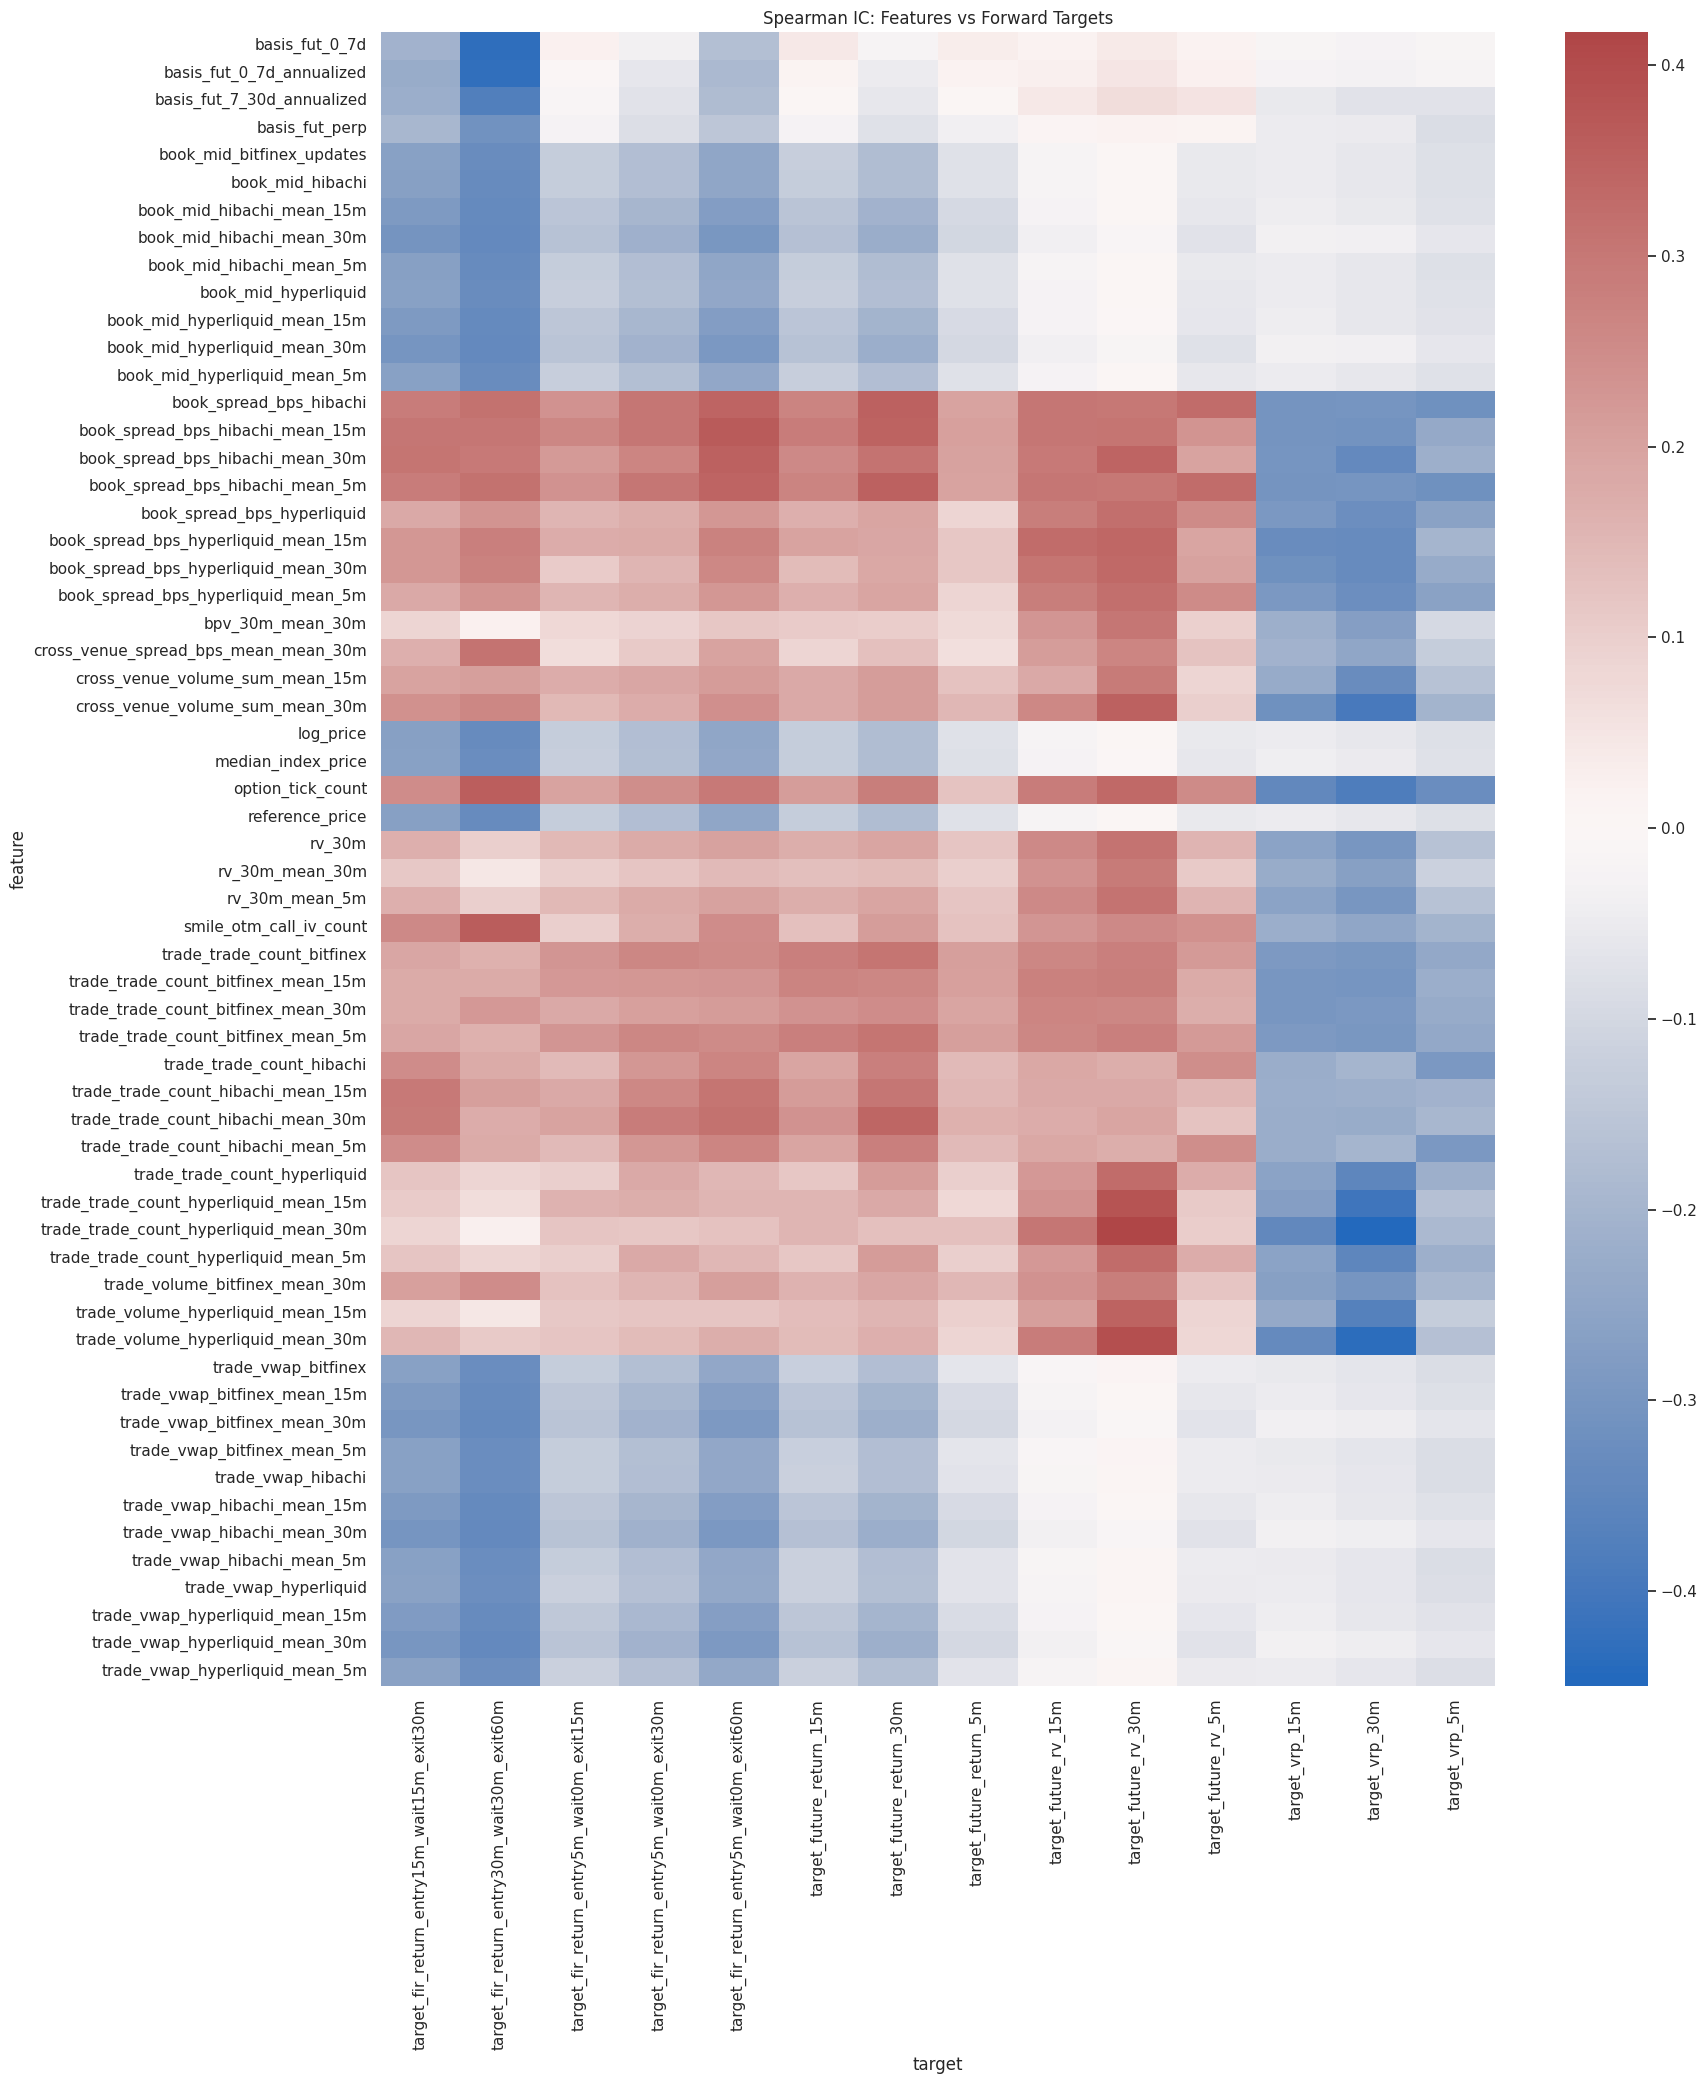

In [5]:
plot_ic_heatmap(ic_table, top_n=60)

## Top IC Bars

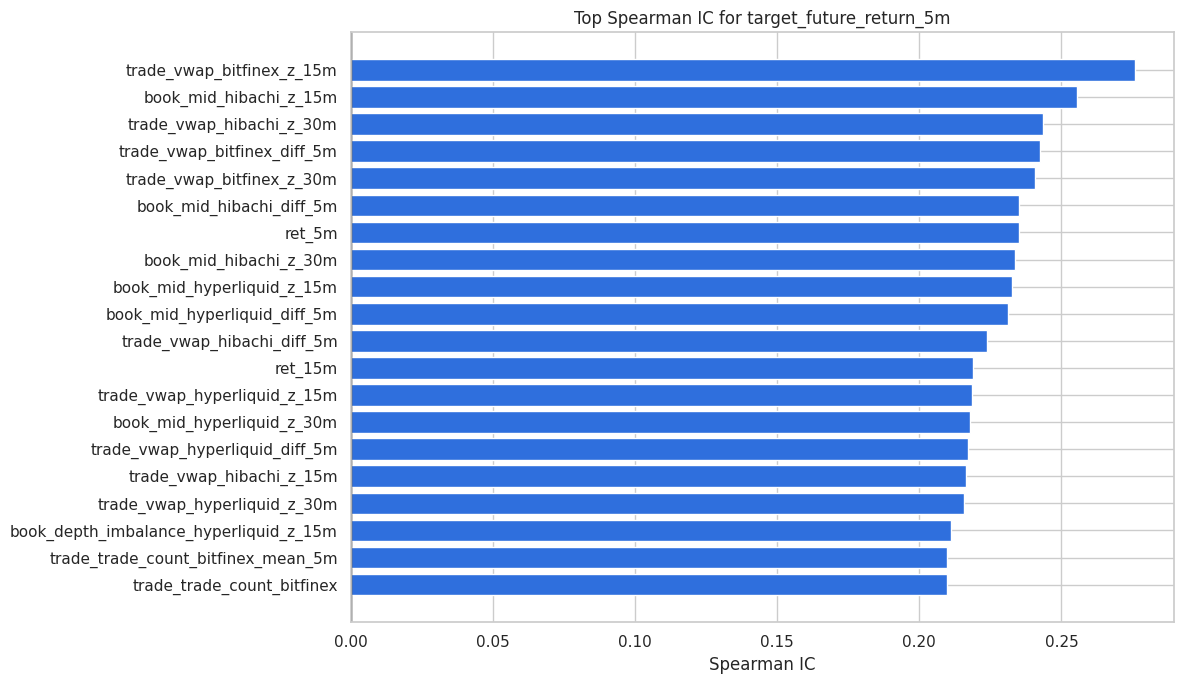

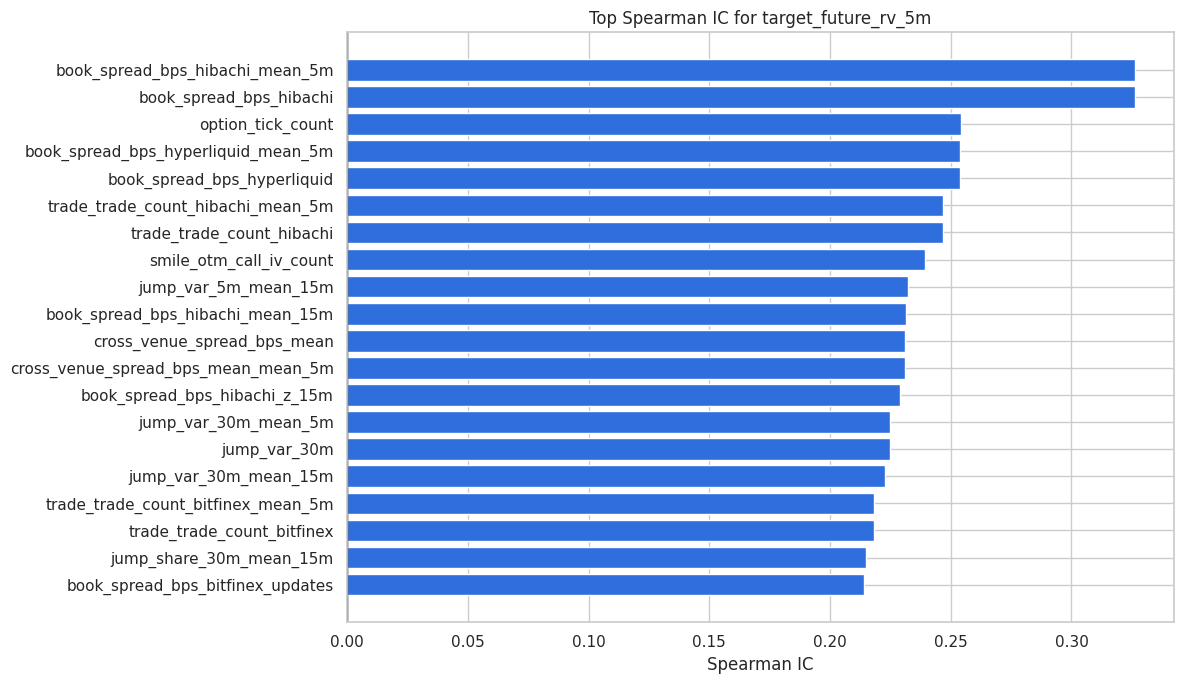

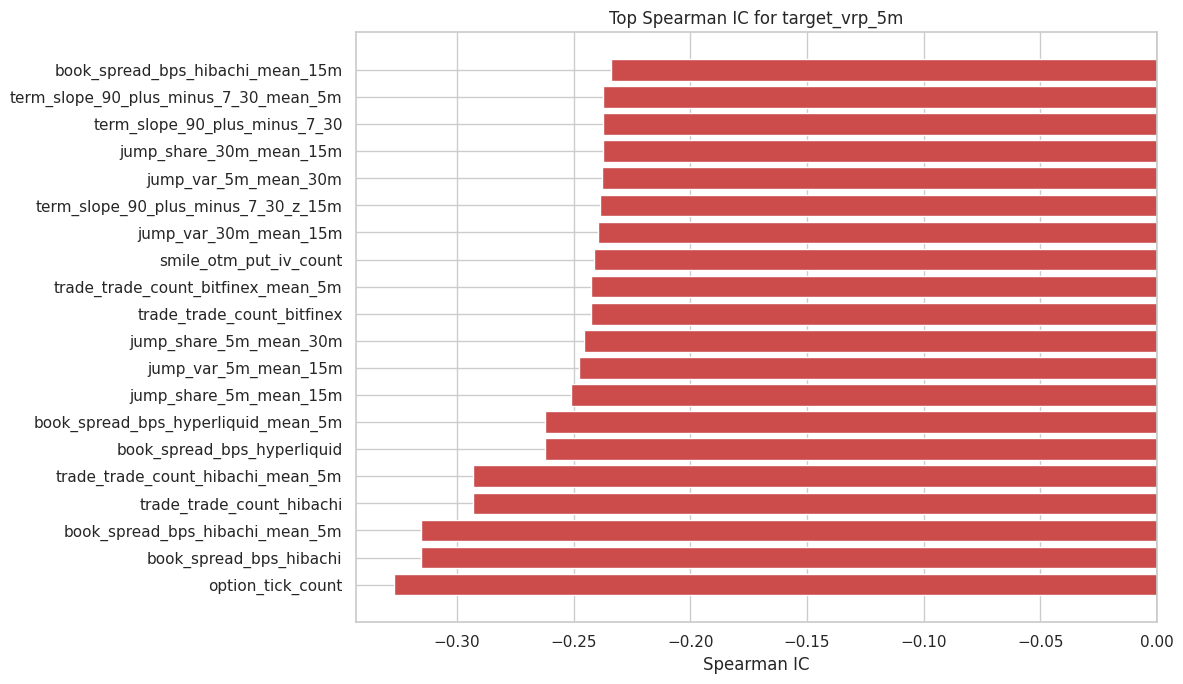

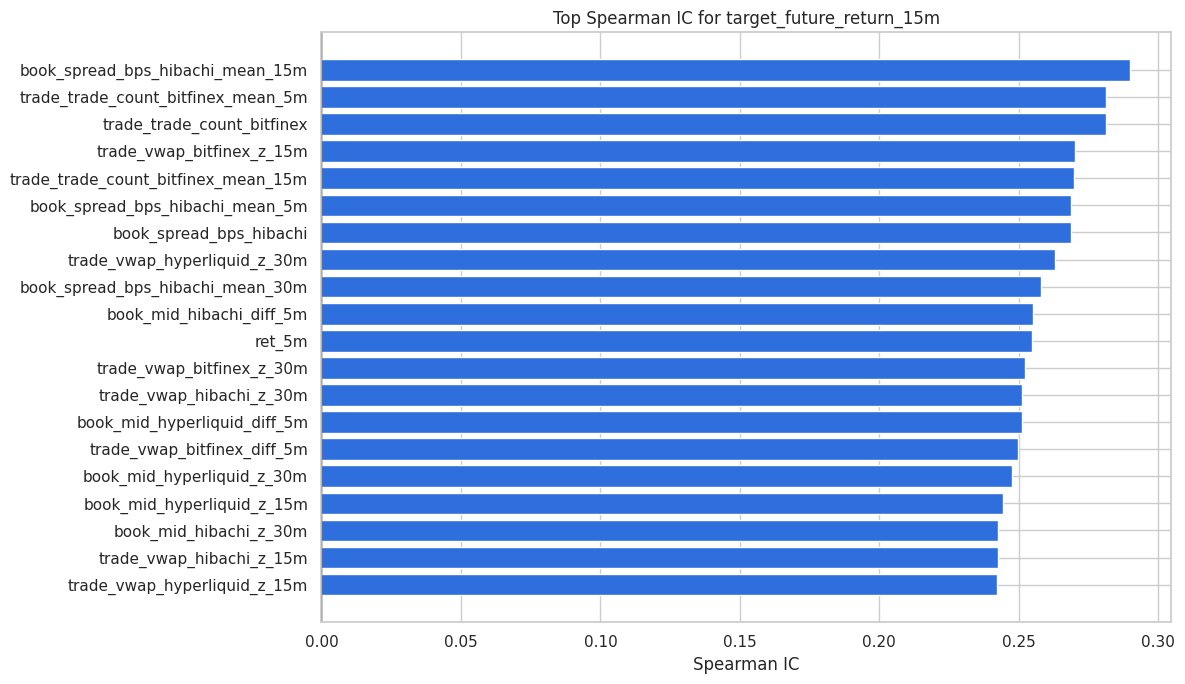

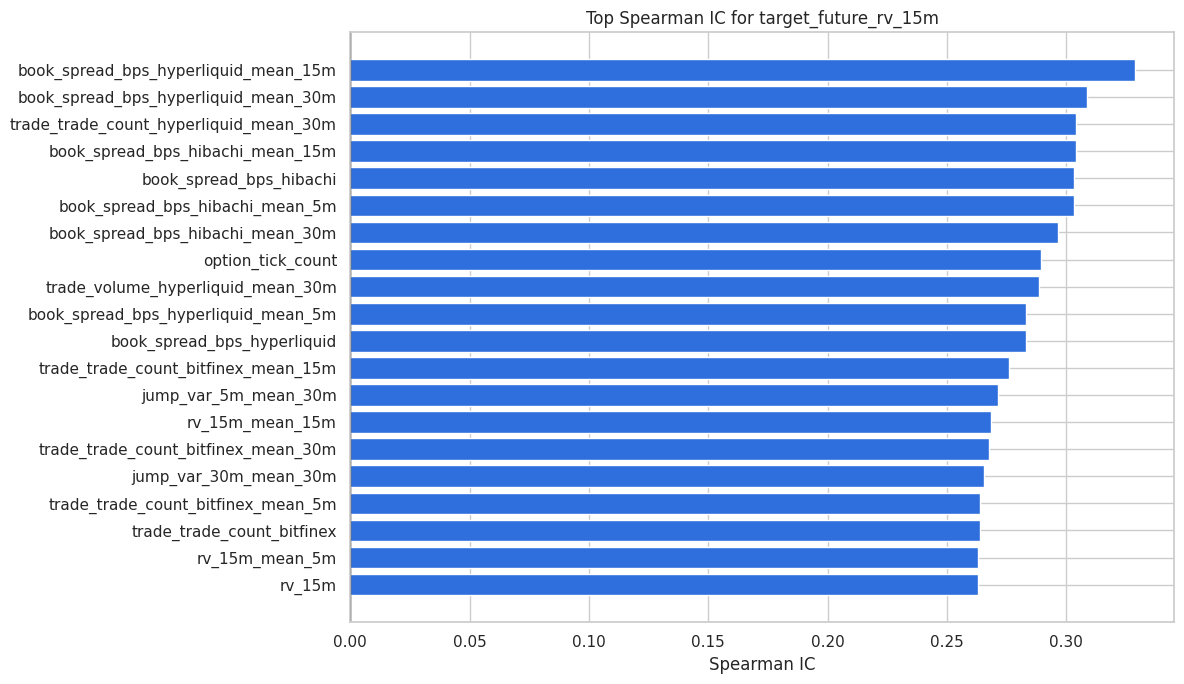

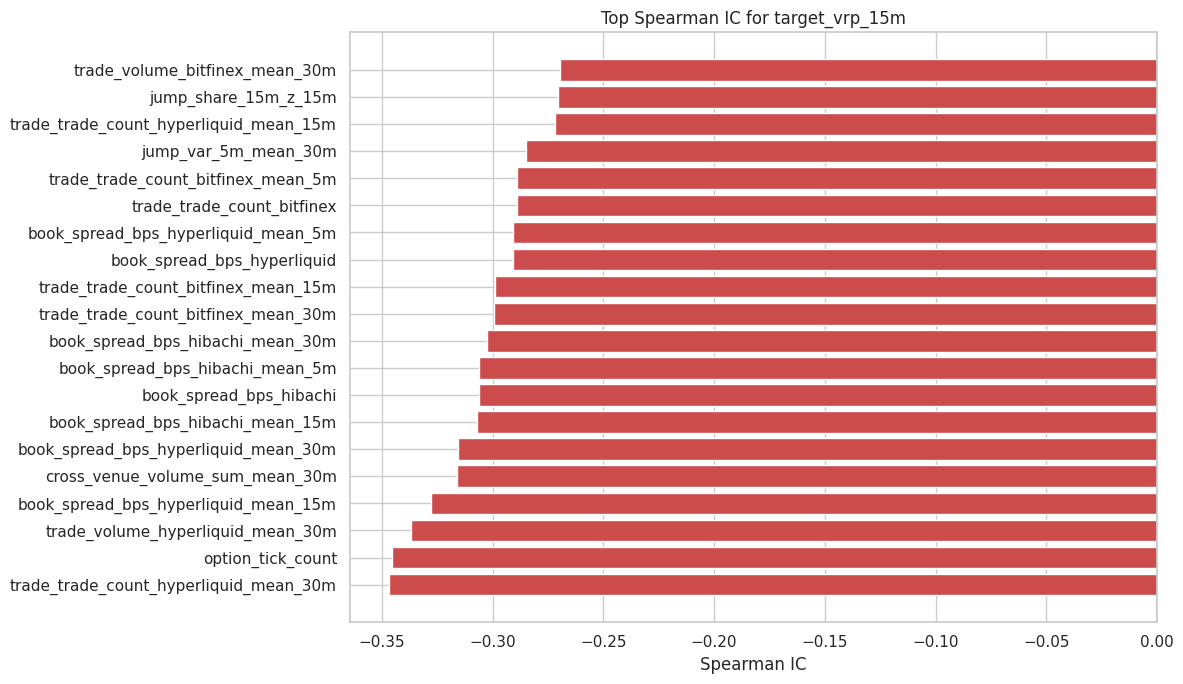

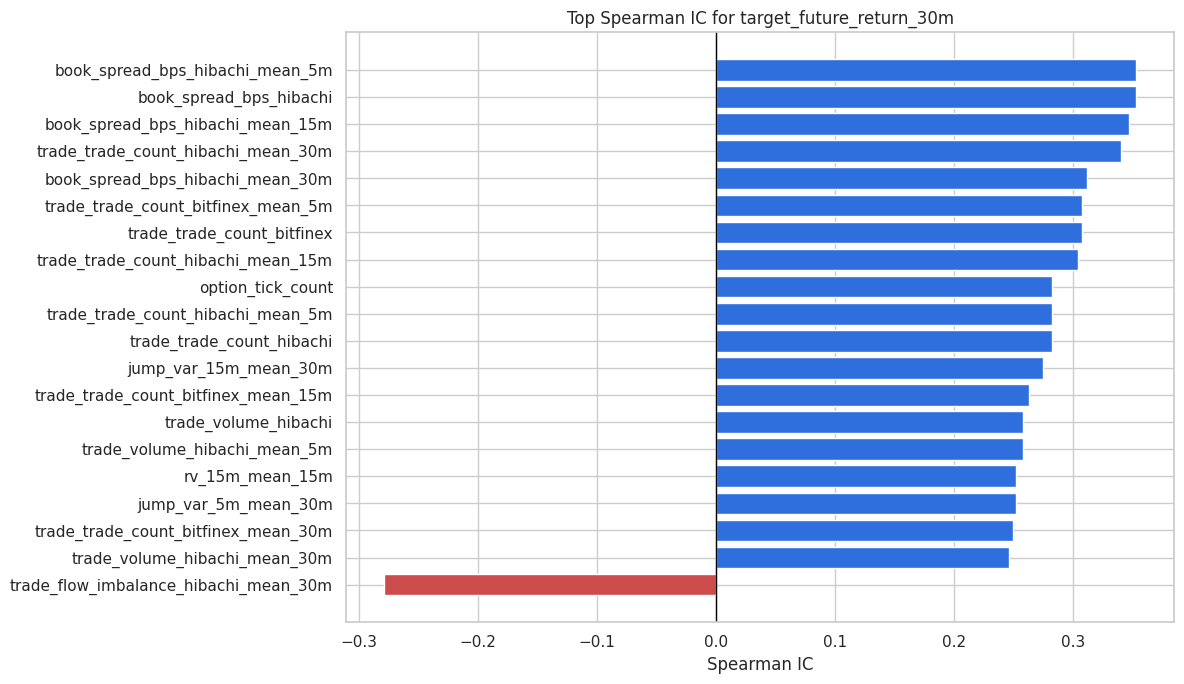

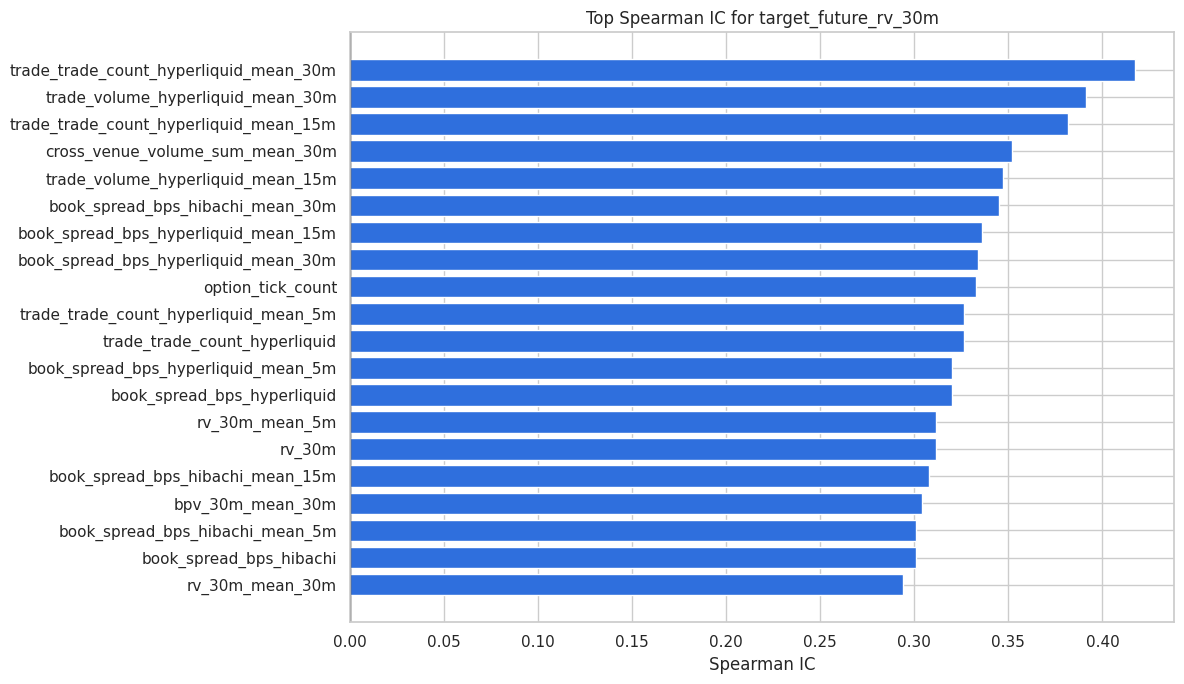

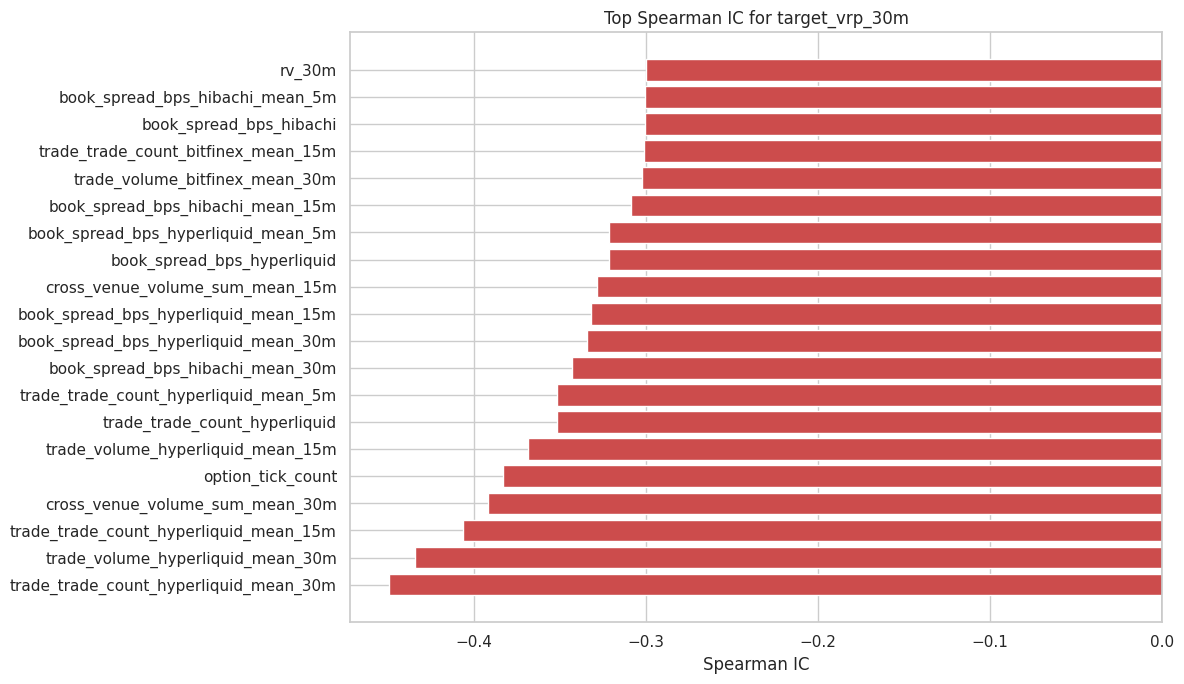

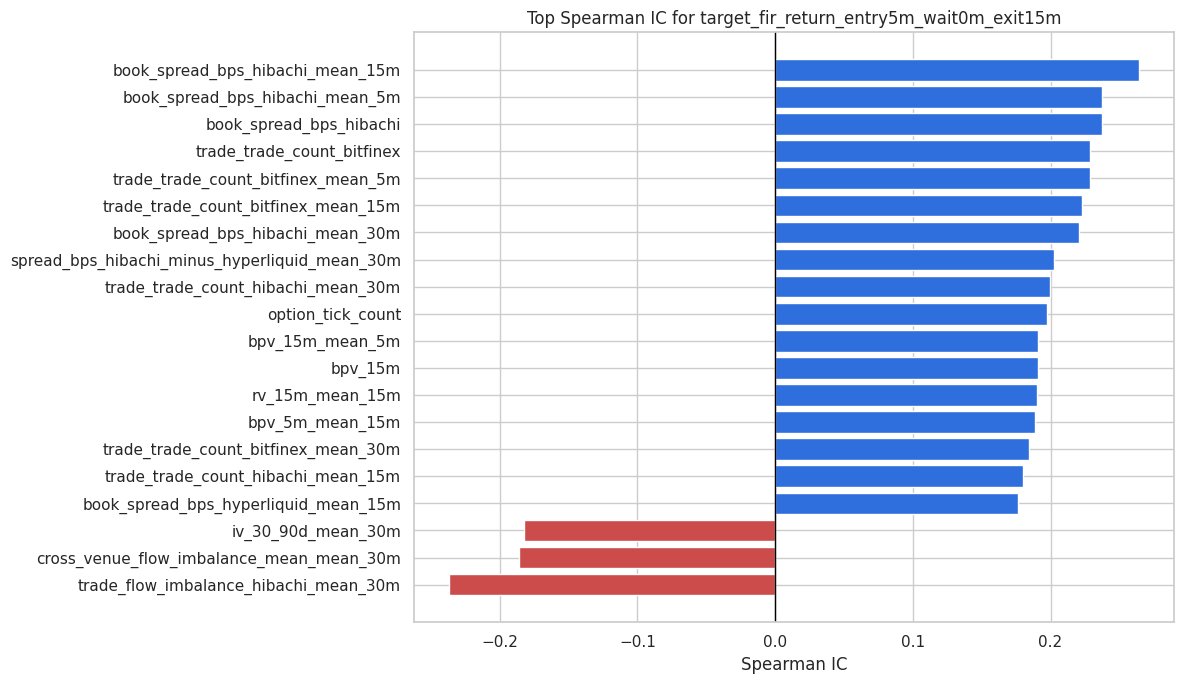

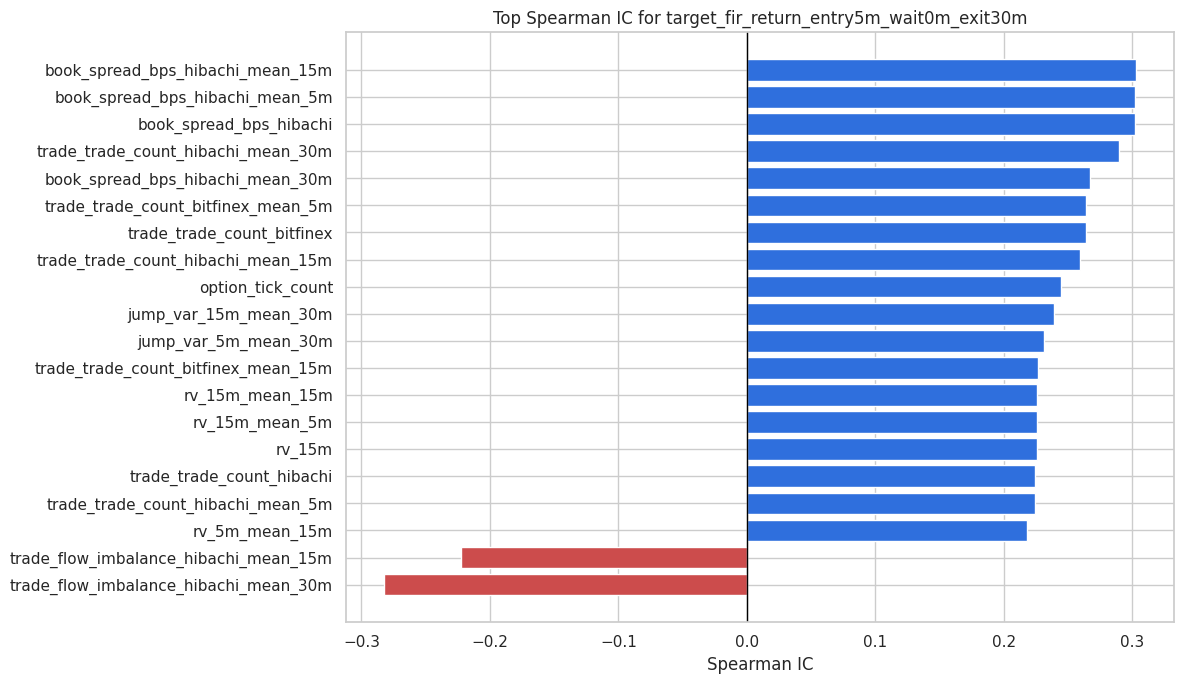

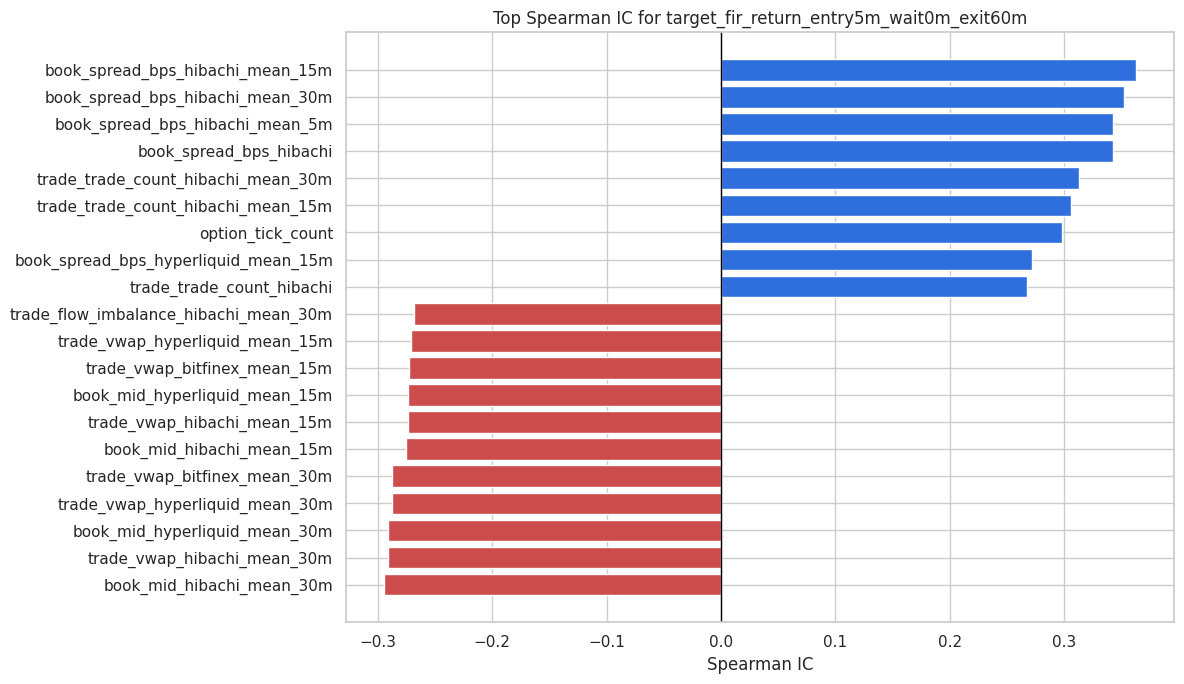

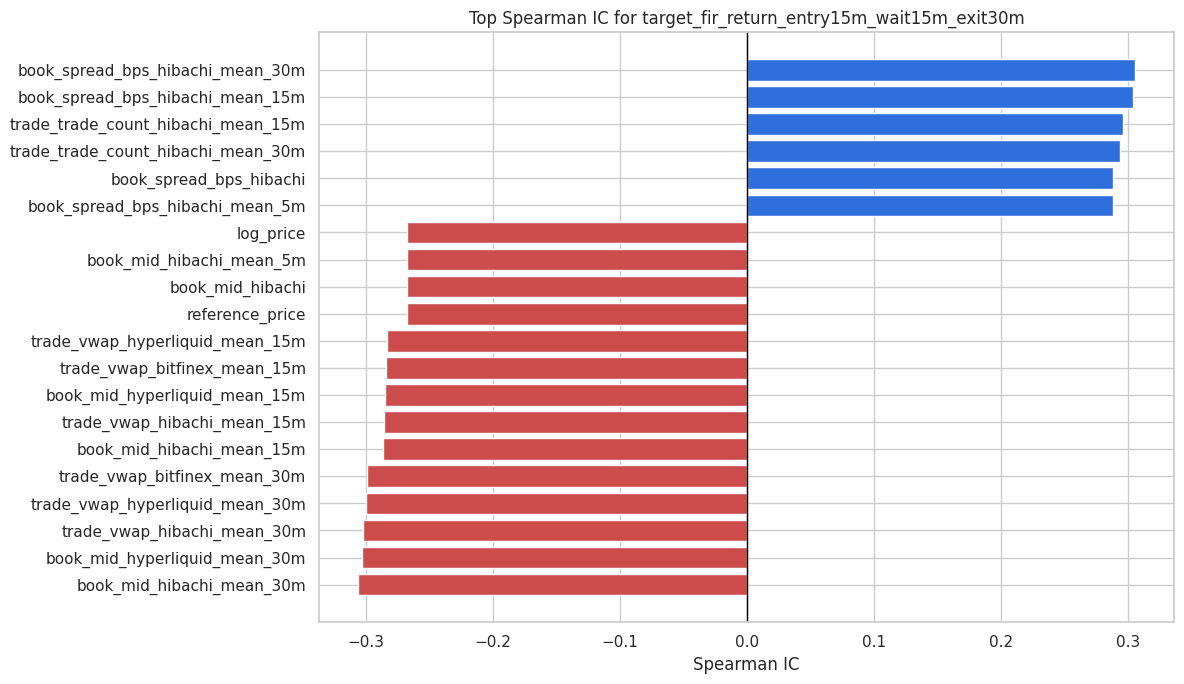

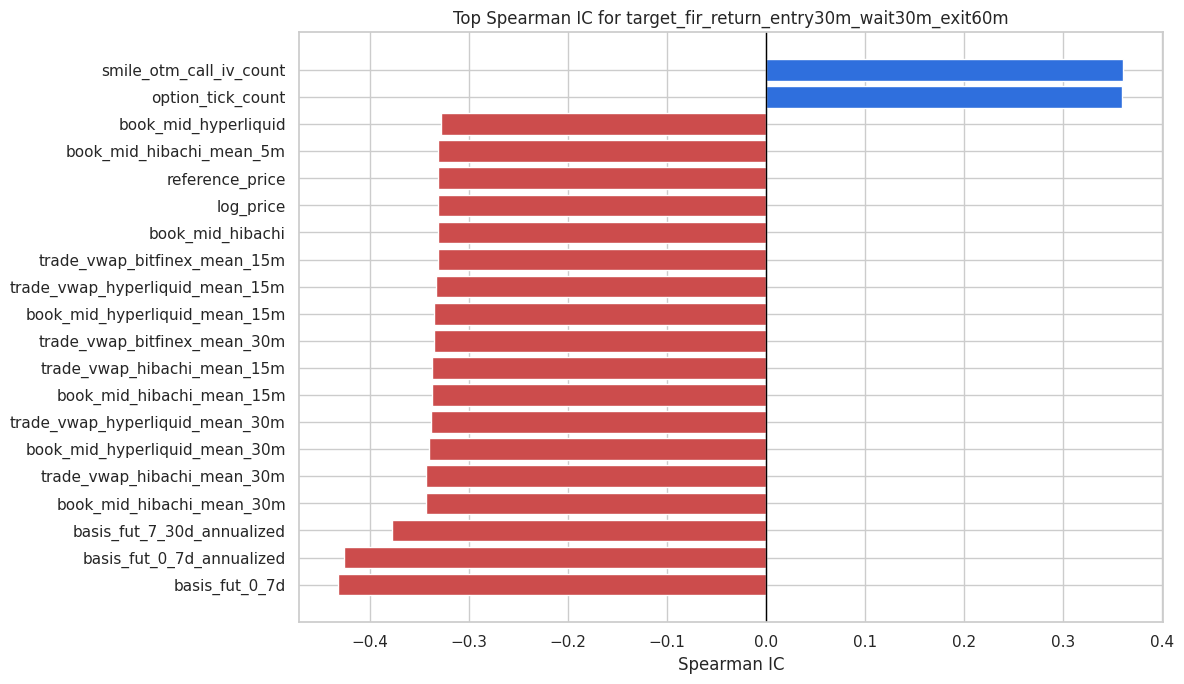

In [6]:
for target in target_columns:
    plot_top_ic_bars(ic_table, target, top_n=20)

## Feature To Target Correlations

In [7]:
target_feature_corr = (
    correlation_matrix.loc[feature_columns, target_columns]
    .stack()
    .rename("spearman_corr")
    .reset_index()
    .rename(columns={"level_0": "feature", "level_1": "target"})
)
target_feature_corr["abs_corr"] = target_feature_corr["spearman_corr"].abs()
target_feature_corr.sort_values("abs_corr", ascending=False).head(80)

,feature,target,spearman_corr,abs_corr
1968,trade_trade_count_hyperliquid_mean_30m,target_vrp_30m,-0.449496,0.449496
2262,trade_volume_hyperliquid_mean_30m,target_vrp_30m,-0.434304,0.434304
1175,basis_fut_0_7d,target_fir_return_entry30m_wait30m_exit60m,-0.431993,0.431993
1245,basis_fut_0_7d_annualized,target_fir_return_entry30m_wait30m_exit60m,-0.425934,0.425934
1967,trade_trade_count_hyperliquid_mean_30m,target_future_rv_30m,0.417195,0.417195
...,...,...,...,...
3043,book_spread_bps_hyperliquid_mean_30m,target_vrp_15m,-0.315415,0.315415
265,book_spread_bps_hibachi,target_fir_return_entry30m_wait30m_exit60m,0.314622,0.314622
2897,book_spread_bps_hibachi_mean_5m,target_fir_return_entry30m_wait30m_exit60m,0.314622,0.314622
1231,basis_fut_perp,target_fir_return_entry30m_wait30m_exit60m,-0.313177,0.313177


## Feature-Feature Correlation Heatmap

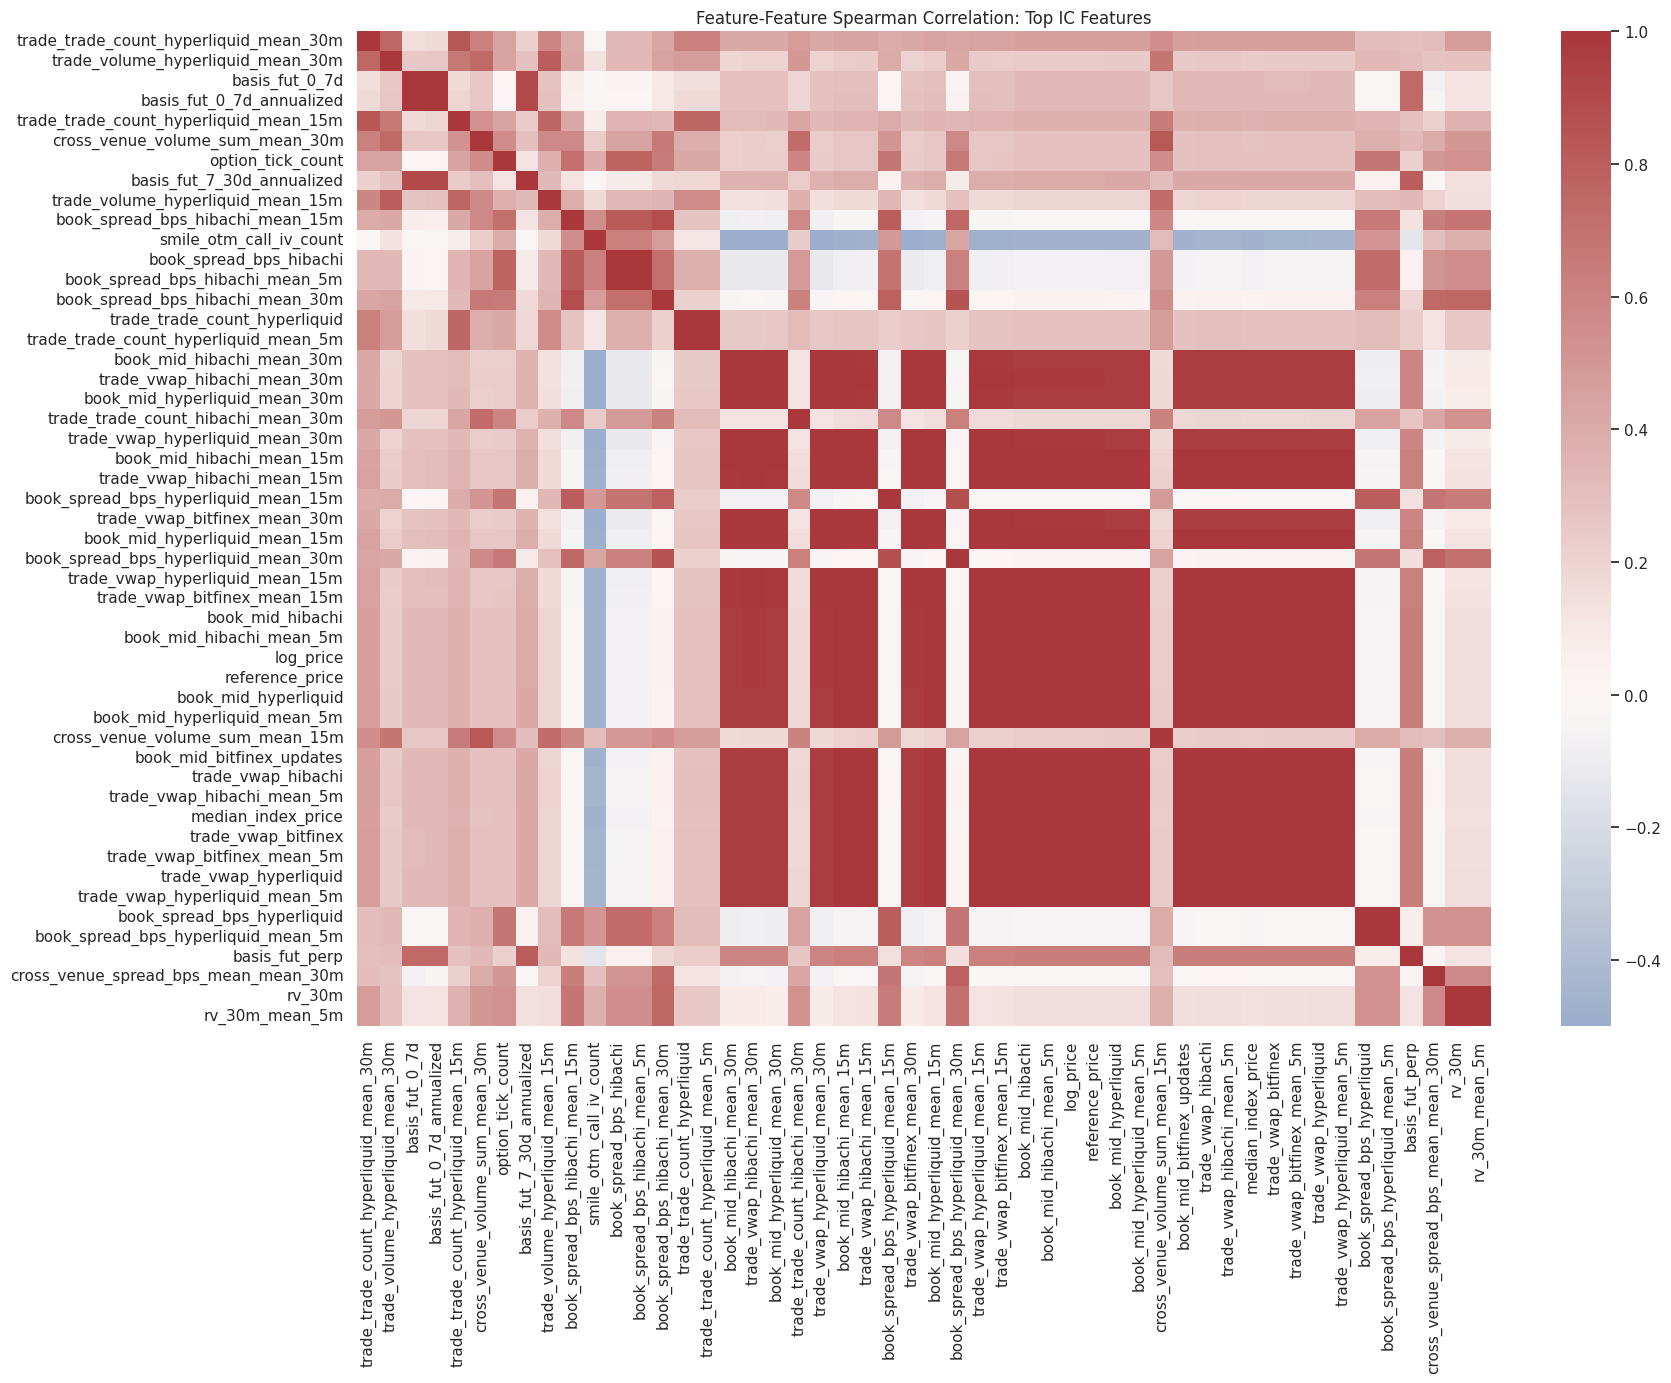

In [8]:
top_features = ic_table.groupby("feature")["abs_ic"].max().nlargest(50).index.tolist()
compact_corr = model_table[top_features].replace([np.inf, -np.inf], np.nan).corr(method="spearman")
plt.figure(figsize=(18, 14))
sns.heatmap(compact_corr, cmap="vlag", center=0, xticklabels=True, yticklabels=True)
plt.title("Feature-Feature Spearman Correlation: Top IC Features")
plt.tight_layout()

## Optional Save

In [9]:
if SAVE_OUTPUTS:
    out_dir = FEATURE_ROOT / DATE / f"bar_{BAR_MINUTES}m"
    out_dir.mkdir(parents=True, exist_ok=True)
    ic_table.to_parquet(out_dir / "ic_table.parquet")
    target_feature_corr.to_parquet(out_dir / "target_feature_correlations.parquet")
    correlation_matrix.to_parquet(out_dir / "spearman_correlation_matrix.parquet")
    print(f"wrote correlation outputs to {out_dir}")
else:
    print("SAVE_OUTPUTS is false; nothing written")

SAVE_OUTPUTS is false; nothing written
